In [3]:
!pip install -q ucimlrepo

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,classification_report
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings("ignore")


In [7]:
wine = fetch_ucirepo(id=109)

X_raw=wine.data.features
y_raw=wine.data.targets.squeeze()

df=X_raw.copy()
df['class']=y_raw.values

print(f"Dataset shape : {df.shape}")
print(f"Classes       : {sorted(df['class'].unique())}")
print(f"Features      : {list(X_raw.columns)}")
df.head()

Dataset shape : (178, 14)
Classes       : [np.int64(1), np.int64(2), np.int64(3)]
Features      : ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [20]:
len(df['class'].unique())

3

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)
X_all_s  = scaler.transform(X)

print(f"Train size: {X_train_s.shape}, Test size: {X_test_s.shape}")

Train size: (142, 13), Test size: (36, 13)


In [17]:
print("Logistic regression:")

def evaluate_clf(X_tr, X_te, y_tr, y_te, label):
    clf = LogisticRegression(max_iter=1000, random_state=42)

    # Train model
    clf.fit(X_tr, y_tr)

    # Predict
    y_pred = clf.predict(X_te)

    # Metrics
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="weighted")

    print(f"\n{'─'*50}")
    print(f"{label}")
    print(f"Accuracy : {acc:.4f}  |  F1 (weighted) : {f1:.4f}")
    print(f"{'─'*50}")
    print(classification_report(y_te, y_pred))

    return acc, f1

acc_orig, f1_orig = evaluate_clf(
    X_train_s, X_test_s, y_train, y_test,
    "Baseline — Original 13 features (scaled)"
)

results = {
    "Original (13 features)": {
        "accuracy": acc_orig,
        "f1": f1_orig
    }
}

Logistic regression:

──────────────────────────────────────────────────
Baseline — Original 13 features (scaled)
Accuracy : 0.9722  |  F1 (weighted) : 0.9720
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



LDA component 1 means: reducing your data from 13 features → 1 new feature
It’s not any single feature : it’s a new feature formed by combining all original features with weights.

──────────────────────────────────────────────────
LDA-1 COMPONENT (LD1 only)
Accuracy : 0.8889  |  F1 (weighted) : 0.8885
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           1       0.80      1.00      0.89        12
           2       0.92      0.79      0.85        14
           3       1.00      0.90      0.95        10

    accuracy                           0.89        36
   macro avg       0.91      0.90      0.89        36
weighted avg       0.90      0.89      0.89        36



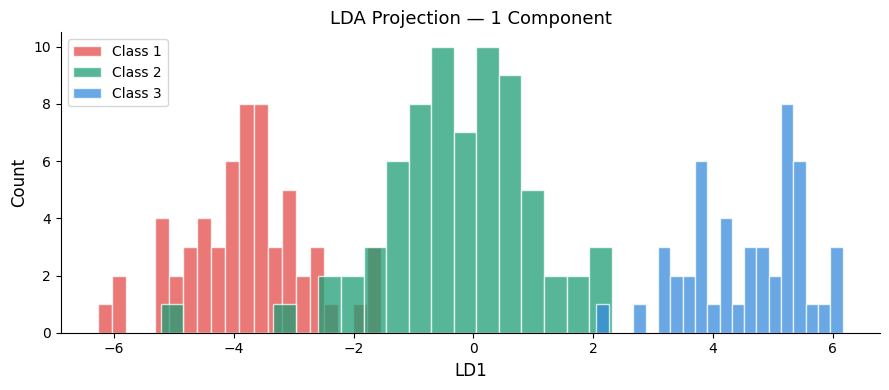

Saved: lda_1d.png


In [19]:
print("LDA component 1 means: reducing your data from 13 features → 1 new feature")
print("It’s not any single feature : it’s a new feature formed by combining all original features with weights.")

lda1=LinearDiscriminantAnalysis(n_components=1)
lda1.fit(X_train_s,y_train)

X_train_lda1=lda1.transform(X_train_s)
X_test_lda1=lda1.transform(X_test_s)
X_all_lda1=lda1.transform(X_all_s)

acc_1d,f1_1d=evaluate_clf(X_train_lda1,X_test_lda1,y_train,y_test,"LDA-1 COMPONENT (LD1 only)")

results["LDA 1D"]={"accuracy": acc_1d,"f1":f1_1d}

#HISTOGRAM:

COLORS = ["#E24B4A", "#1D9E75", "#378ADD"]
fig, ax = plt.subplots(figsize=(9, 4))
for i, cls in enumerate(classes):
    mask = y == cls
    ax.hist(X_all_lda1[mask, 0], bins=20, alpha=0.75,
            color=COLORS[i], label=f"Class {cls}", edgecolor="white")
ax.set_xlabel("LD1", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("LDA Projection — 1 Component", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lda_1d.png", dpi=150)
plt.show()
print("Saved: lda_1d.png")

LDA 2 components

──────────────────────────────────────────────────
LDA-2 COMPONENTS(LD1+LD2)
Accuracy : 0.9722  |  F1 (weighted) : 0.9720
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



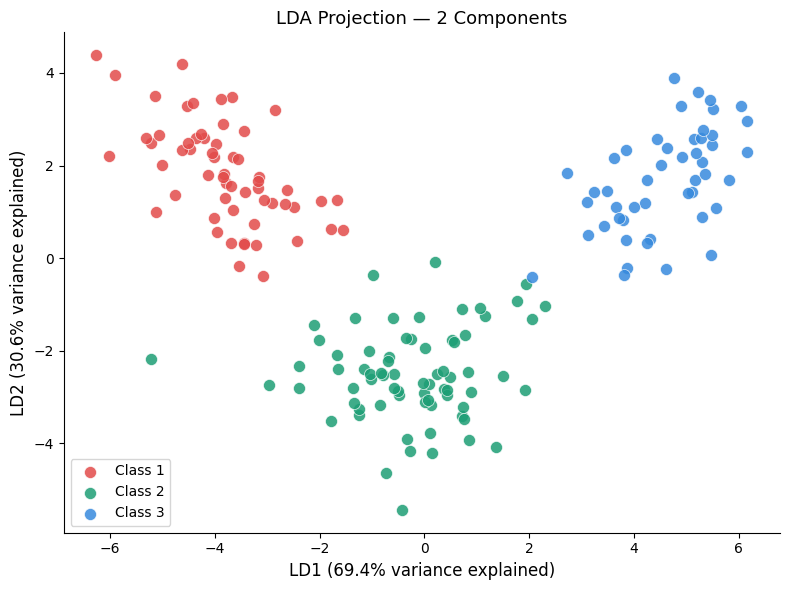

Saved: lda_2d.png


In [21]:
print("LDA 2 components")

lda2=LinearDiscriminantAnalysis(n_components=2)
lda2.fit(X_train_s,y_train)

X_train_lda2=lda2.transform(X_train_s)
X_test_lda2=lda2.transform(X_test_s)
X_all_lda2=lda2.transform(X_all_s)

acc_2d,f1_2d=evaluate_clf(
    X_train_lda2,X_test_lda2,y_train,y_test,"LDA-2 COMPONENTS(LD1+LD2)"
)

results["LDA 2D"]={"accuracy": acc_2d, "f1": f1_2d}

#SCATTER PLOT:
pct = lda2.explained_variance_ratio_ * 100
fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(classes):
    mask = y == cls
    ax.scatter(X_all_lda2[mask, 0], X_all_lda2[mask, 1],
               color=COLORS[i], label=f"Class {cls}",
               alpha=0.85, edgecolors="white", s=75, linewidths=0.5)
ax.set_xlabel(f"LD1 ({pct[0]:.1f}% variance explained)", fontsize=12)
ax.set_ylabel(f"LD2 ({pct[1]:.1f}% variance explained)", fontsize=12)
ax.set_title("LDA Projection — 2 Components", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lda_2d.png", dpi=150)
plt.show()
print("Saved: lda_2d.png")


In [22]:
clf2 = LogisticRegression(max_iter=1000, random_state=42)
clf2.fit(X_train_lda2, y_train)
y_pred2 = clf2.predict(X_test_lda2)

# Side by side comparison
print("Sample   Actual   Predicted   Correct?")
print("-" * 40)
for i, (actual, predicted) in enumerate(zip(y_test, y_pred2)):
    status = "✓" if actual == predicted else "✗ WRONG"
    print(f"  {i:<7} {actual:<9} {predicted:<12} {status}")

print("-" * 40)
correct = sum(y_test == y_pred2)
total   = len(y_test)
print(f"\nTotal Correct   : {correct}/{total}")
print(f"Total Wrong     : {total - correct}/{total}")
print(f"Accuracy        : {correct/total:.4f}")

Sample   Actual   Predicted   Correct?
----------------------------------------
  0       1         1            ✓
  1       3         3            ✓
  2       1         1            ✓
  3       2         2            ✓
  4       2         2            ✓
  5       1         1            ✓
  6       1         1            ✓
  7       2         2            ✓
  8       2         2            ✓
  9       3         3            ✓
  10      2         2            ✓
  11      3         3            ✓
  12      1         1            ✓
  13      3         2            ✗ WRONG
  14      1         1            ✓
  15      2         2            ✓
  16      2         2            ✓
  17      1         1            ✓
  18      2         2            ✓
  19      1         1            ✓
  20      2         2            ✓
  21      2         2            ✓
  22      1         1            ✓
  23      1         1            ✓
  24      2         2            ✓
  25      2         2            ✓
  26

In [23]:
df_proj = pd.DataFrame({
    "SampleId" : range(len(y)),
    "LD1"      : X_all_lda2[:, 0],
    "LD2"      : X_all_lda2[:, 1],
    "Class"    : y
})
df_proj.to_csv("lda_projection.csv", index=False)
print(f"Saved: lda_projection.csv  →  shape {df_proj.shape}")
df_proj.head()

Saved: lda_projection.csv  →  shape (178, 4)


,SampleId,LD1,LD2,Class
0,0,-5.000553,2.001031,1
1,1,-4.768582,1.370004,1
2,2,-3.795781,1.629788,1
3,3,-4.633169,4.188602,1
4,4,-1.773728,0.625984,1


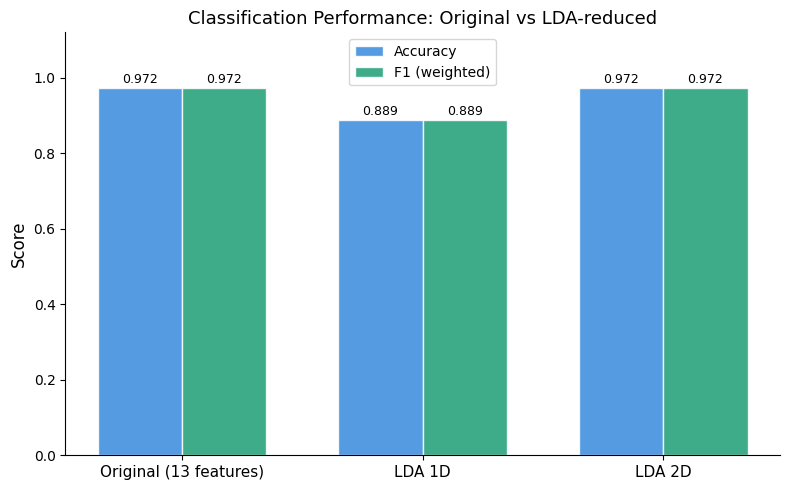

Saved: metrics_comparison.png


In [24]:
labels = list(results.keys())
accs   = [results[k]["accuracy"] for k in labels]
f1s    = [results[k]["f1"]       for k in labels]
x      = np.arange(len(labels))
w      = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, accs, w, label="Accuracy",      color="#378ADD", alpha=0.85, edgecolor="white")
b2 = ax.bar(x + w/2, f1s,  w, label="F1 (weighted)", color="#1D9E75", alpha=0.85, edgecolor="white")

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Classification Performance: Original vs LDA-reduced", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()
print("Saved: metrics_comparison.png")

In [25]:
from google.colab import files
for fname in ["lda_projection.csv", "lda_1d.png", "lda_2d.png", "metrics_comparison.png"]:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>